<a href="https://colab.research.google.com/github/shaan-byte/python_ds_colab/blob/main/Seaborn_Practical_Session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Data with Seaborn — The Practical Session
### Masai School · Data Science & AI Program — Module 2, closing session

**The story of this notebook:** you run a small restaurant. You saved every receipt
for three months — **244 of them**. Each receipt records the bill, the tip, the party
size, the day, and the time. We will make this data *speak* using pictures.

**What we cover (the four pending topics):**
1. Seaborn — practical implementation
2. Statistical plots (histogram, KDE, box, violin, scatter, bar)
3. Heatmaps for correlation
4. Matplotlib vs Seaborn — a practical comparison

**How to use this notebook:**
- Run each cell with **Shift + Enter** (or the ▶ button on the left of a cell).
- Run cells **top to bottom** — later cells use things created earlier.
- Nothing to install: Colab already has every library we need.
- After each plot, read the "**How to read this chart**" note below it.

> A gentle promise: every line of plotting code in this notebook is explained
> in plain English, right where it appears. If you can read a sentence,
> you can read this code.

---
## 0 · Setup — two imports you will type forever

- **matplotlib** is the *drawing engine*. It puts ink on the canvas.
- **seaborn** is the *statistical layer* that sits on top of matplotlib.
  You give it a table and column names; it does the math and the styling.

`sns` and `plt` are the universal nicknames — every tutorial on Earth uses them.

In [ ]:
data={'Name':'Rajiv', "Age":43,"address":"Pune"}
print(data)

{'Name': 'Rajiv', 'Age': 43, 'address': 'Pune'}


In [ ]:
import matplotlib.pyplot as plt   # the drawing engine (nickname: plt)
import seaborn as sns              # the statistical layer on top (nickname: sns)
import pandas as pd                # tables (you know this one from Module 2)
import numpy as np                 # numbers (this one too)

sns.set_theme()   # switch ON seaborn's clean look for ALL plots from here on

print("seaborn version:", sns.__version__)   # just to confirm everything loaded

seaborn version: 0.13.2


---
## 1 · Why pictures beat tables — the famous warning

Before any Seaborn, one demonstration of **why plotting is not optional**.

In 1973 the statistician Francis Anscombe built four small datasets.
All four have the **same mean, same spread, same correlation, and the same
best-fit line**. A summary table swears they are identical. Let's check the
summaries first, then look at them.

In [ ]:
# Load Anscombe's quartet — it ships with seaborn as a practice dataset
anscombe = sns.load_dataset("anscombe")   # download a small built-in table

# Group by dataset (I, II, III, IV) and compare their summary numbers
summary = anscombe.groupby("dataset").agg(
    mean_x=("x", "mean"),     # average of x in each dataset
    mean_y=("y", "mean"),     # average of y in each dataset
    corr=("x", lambda s: s.corr(anscombe.loc[s.index, "y"]))  # correlation x↔y
).round(2)
summary

,mean_x,mean_y,corr
dataset,,,
I,9.0,7.5,0.82
II,9.0,7.5,0.82
III,9.0,7.5,0.82
IV,9.0,7.5,0.82


Four rows, nearly identical numbers. **Same data, right?** Now plot them.

Reading the plotting line below, word by word:
- `sns.lmplot(...)` — "seaborn, draw a scatter **plus a fitted line**" (lm = line model)
- `data=anscombe` — from this table
- `x="x", y="y"` — these columns on the axes
- `col="dataset"` — make one **panel per dataset** (I, II, III, IV)
- `height=2.6` — each panel 2.6 inches tall (just sizing)

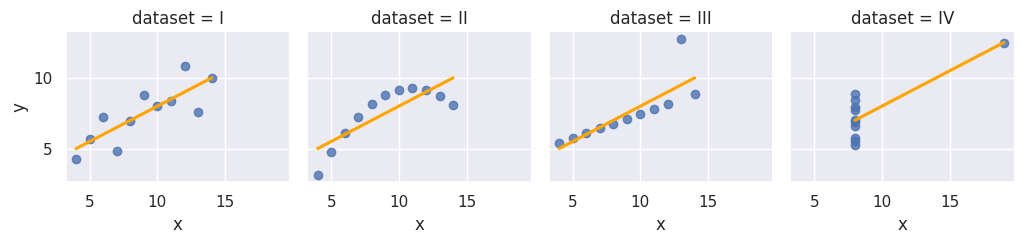

In [ ]:
sns.lmplot(data=anscombe,        # the table to read from
           x="x", y="y",         # which columns go on the axes
           col="dataset",        # one panel per value of 'dataset' → 4 panels
           height=2.6,           # panel height in inches
           ci=None,              # hide the confidence band (cleaner for now)
           line_kws={"color": "orange"})   # make the fitted line orange
plt.show()   # render everything drawn so far

**How to read this chart:** same stats, four different realities —
a clean trend (I), a curve (II), a line hijacked by one outlier (III),
and a "trend" invented by a single point (IV).

> **The lesson of this whole session:** summary numbers are the *start* of
> understanding, never the end. **If you have not plotted it, you do not know it.**

---
## 2 · Meet the data — 244 real receipts

Seaborn bundles the famous **tips** dataset: 244 restaurant receipts.
`load_dataset` hands it to us as a regular pandas DataFrame.

In [ ]:
tips = sns.load_dataset("tips")   # 244 receipts, as a pandas DataFrame

tips.head()   # peek at the first 5 rows — ALWAYS do this first

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Seven columns, two *kinds* — this distinction decides every plot we draw today:

| column | meaning | kind |
|---|---|---|
| `total_bill` | bill in dollars | **numeric** |
| `tip` | tip in dollars | **numeric** |
| `size` | people at the table | **numeric** |
| `sex`, `smoker`, `day`, `time` | who/where/when | **category** |

In [ ]:
tips.info()    # column types + row count — check for missing values too

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
tips.describe().round(2)   # quick summary of the numeric columns

# Read from this: average bill $19.79, average tip $3.00,
# biggest bill $50.81, biggest tip $10.00

,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


**The one sentence that is all of Seaborn.** Nearly every call looks like:

```python
sns.plotname(data=your_table, x="a column", y="a column", hue="a category")
```

- `plotname` — what to draw (`histplot`, `boxplot`, `scatterplot`, `heatmap` …)
- `data=` — which DataFrame
- `x=`, `y=` — which columns on which axes (names in quotes)
- `hue=` — *optional*: split by a category using **color**

Memorize that sentence and you have memorized the library.

---
## 3 · Histograms & KDE — the shape of one column

**Business question: "What does a typical bill look like?"**

Picture sorting receipts into labelled buckets ($0–5, $5–10, …) and stacking
them. The stacks form a skyline. That skyline is the **histogram**; each
bucket is a **bin**.

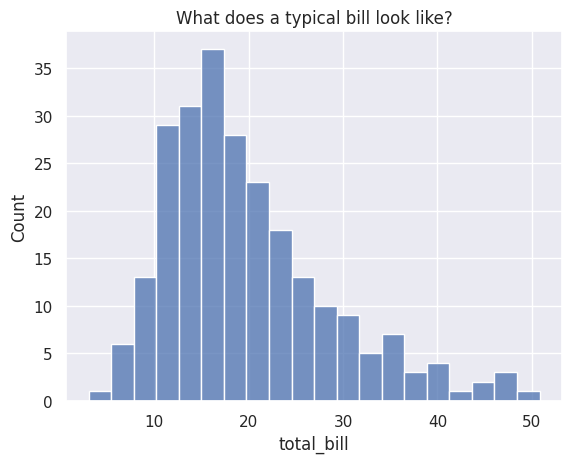

In [ ]:
sns.histplot(data=tips,          # the table
             x="total_bill",     # the numeric column whose shape we want
             bins=20)            # slice its range into 20 equal buckets
plt.title("What does a typical bill look like?")   # matplotlib adds the title
plt.show()

**How to read this chart:** bills pile up between \$10–20, then a long
**right tail** trails out to \$50. That tail is why the mean (\$19.79) sits
*above* the median (\$17.80) — a few monster tables drag the average up.
Money data almost always looks like this ("right-skewed").

**Now the classic experiment — the same data with different bins:**

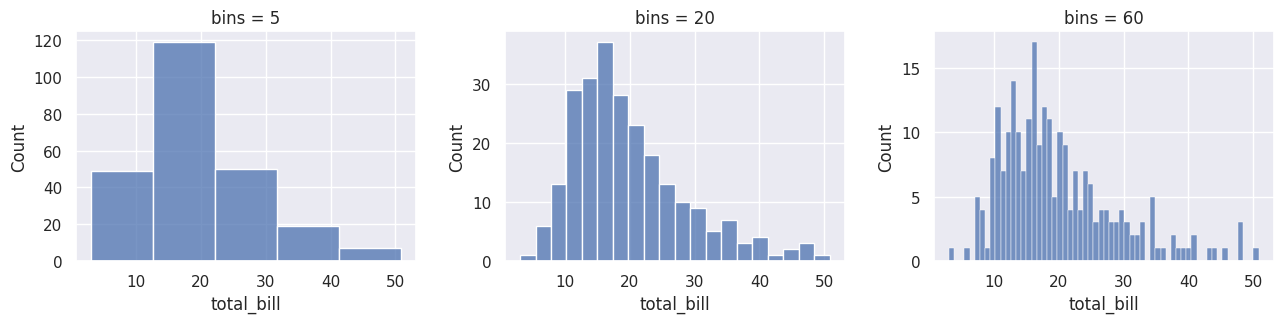

In [ ]:
# One figure, three panels side by side: same data, three bin choices
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))   # 1 row, 3 plot slots

for ax, n_bins in zip(axes, [5, 20, 60]):           # try 5, then 20, then 60 bins
    sns.histplot(data=tips, x="total_bill", bins=n_bins, ax=ax)  # draw INTO slot ax
    ax.set_title(f"bins = {n_bins}")                # label each panel

plt.tight_layout()   # stop the panels from overlapping each other
plt.show()

# 5 bins: shape almost gone. 20: readable. 60: shape + noise mixed together.

**KDE — the smooth cousin.** Put a tiny smooth bump on every receipt and
add up all 244 bumps → one smooth curve (KDE = kernel density estimate).
`kde=True` overlays it on the histogram:

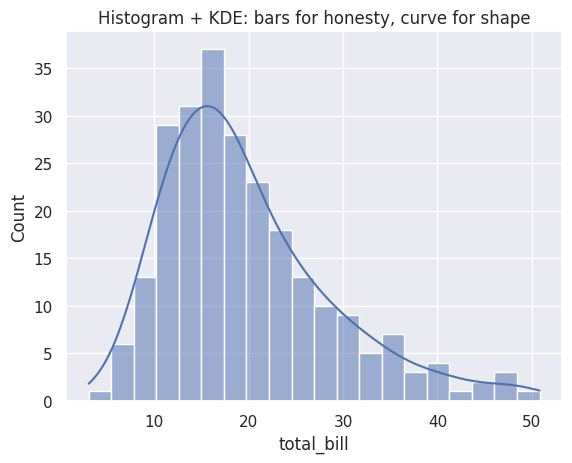

In [ ]:
sns.histplot(data=tips, x="total_bill",
             bins=20,
             kde=True)     # add the smooth KDE curve on top of the bars
plt.title("Histogram + KDE: bars for honesty, curve for shape")
plt.show()

> **Pitfall to remember:** the same data can look smooth or chaotic depending
> on the bin count — never read a histogram without asking *"how many bins?"*.
> And the KDE can smear density where no data exists (it happily drifts
> below \$0). Trust it for shape, not for exact edges.

---
## 4 · Box plots — five numbers, one glyph

**Business question: "Are Saturday bills bigger than Thursday bills?"**

A box plot is the dataset's ID card:
- the **line** in the middle = the **median** (half below, half above)
- the **box** = from **Q1** to **Q3** — where the middle 50% of values live
- the **whiskers** = how far "normal" stretches (up to 1.5 × IQR past the box)
- the **dots** = **outliers** — values beyond the whiskers, flagged for attention

First, let's compute those five numbers *by hand* on nine real tips,
so the glyph is never a mystery:

In [ ]:
nine_tips = pd.Series([1.00, 1.50, 2.00, 2.00, 2.50, 3.00, 3.50, 4.00, 9.00])

median = nine_tips.median()                 # the middle value of the sorted list
q1 = nine_tips[:4].median()                 # median of the lower half → Q1
q3 = nine_tips[5:].median()                 # median of the upper half → Q3
iqr = q3 - q1                               # the box width (interquartile range)
fence = q3 + 1.5 * iqr                      # anything beyond this = outlier

print(f"median = {median}   Q1 = {q1}   Q3 = {q3}   IQR = {iqr}")
print(f"upper fence = {q3} + 1.5×{iqr} = {fence}")
print(f"is the $9.00 tip an outlier?  {9.00 > fence}")   # → True: drawn as a dot

median = 2.5   Q1 = 1.75   Q3 = 3.75   IQR = 2.0
upper fence = 3.75 + 1.5×2.0 = 6.75
is the $9.00 tip an outlier?  True


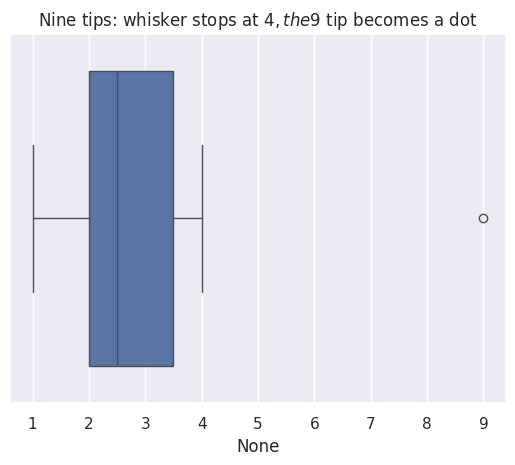

In [ ]:
sns.boxplot(x=nine_tips)                       # draw the box for our 9 tips
plt.title("Nine tips: whisker stops at $4, the $9 tip becomes a dot")
plt.show()

**Now the real question — one box per day.** Note the pattern:
`x` gets a **category** (day), `y` gets a **number** (total_bill).

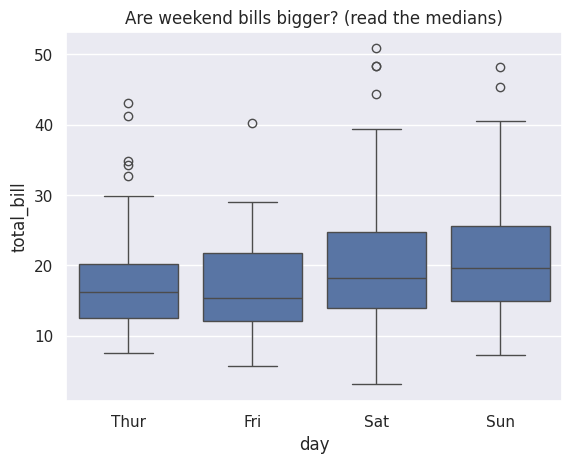

In [ ]:
sns.boxplot(data=tips,
            x="day",           # a CATEGORY → one box per day
            y="total_bill")    # a NUMBER → what each box summarizes
plt.title("Are weekend bills bigger? (read the medians)")
plt.show()

**How to read this chart:** Saturday's and Sunday's boxes sit visibly higher
than Thursday's — weekend tables spend more. The dots above the whiskers are
big-spending outlier tables (real receipts, not errors — flags, not verdicts).

> **Pitfall:** an outlier is a *flag*, not a *verdict*. The \$9 tip might be a
> typo — or a delighted customer. The box plot points; investigating is your job.

---
## 5 · Violin plots — when the box lies

A box plot has one blind spot: it cannot show **two crowds** hiding in one column.

Watch it fail. A café has a breakfast rush (~8:30) and a dinner rush (~19:00).
The median arrival time is ~2 pm — **when the café is empty**:

In [ ]:
rng = np.random.default_rng(23)          # random generator with a fixed seed
morning = rng.normal(8.5, 0.8, 40)        # 40 arrivals around 8:30 am
evening = rng.normal(19.0, 0.9, 40)       # 40 arrivals around 7:00 pm
arrivals = pd.Series(np.concatenate([morning, evening]))   # one column, 80 values

print(f"median arrival = {arrivals.median():.1f}  (≈ 2 pm)")
print("arrivals between 1 pm and 3 pm:", ((arrivals > 13) & (arrivals < 15)).sum())

median arrival = 13.1  (≈ 2 pm)
arrivals between 1 pm and 3 pm: 0


**How to read a violin:** it is a box plot wearing the KDE as skin —
**fat where data is dense, thin where it is sparse** (mirrored for symmetry).
Two bulges = two crowds. The box physically cannot show that.

On the real receipts, violins work the same one-liner way:

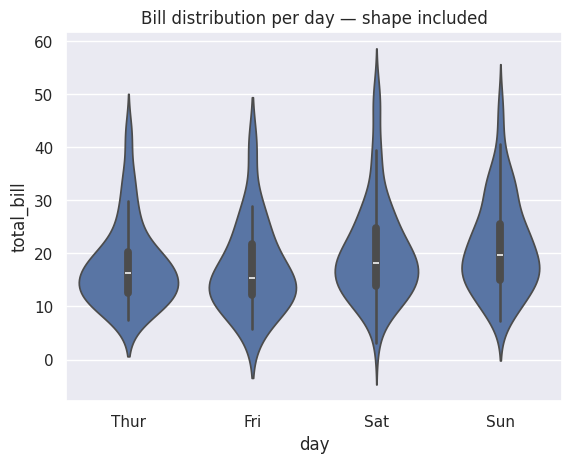

In [ ]:
sns.violinplot(data=tips, x="day", y="total_bill")   # same grammar as boxplot
plt.title("Bill distribution per day — shape included")
plt.show()

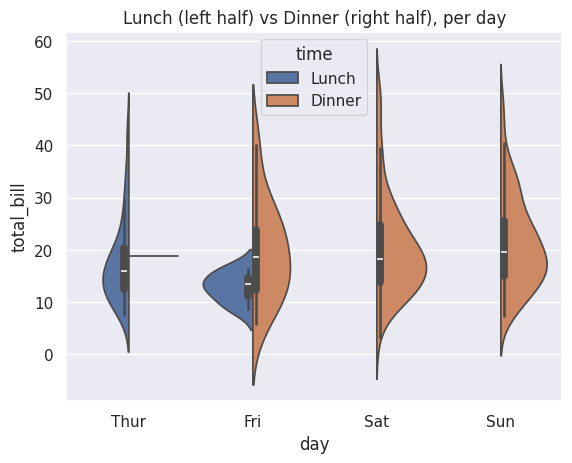

In [ ]:
# Bonus: split violins — two categories compared inside ONE glyph
sns.violinplot(data=tips,
               x="day", y="total_bill",
               hue="time",        # color by Lunch / Dinner…
               split=True)        # …and draw each half-violin per group
plt.title("Lunch (left half) vs Dinner (right half), per day")
plt.show()

> **Pitfall:** a violin's outline is a KDE, and a KDE built from 5 points is
> fiction wearing a suit. Under ~30 points per group, show the points instead:
> `sns.stripplot(...)` or `sns.swarmplot(...)`.

---
## 6 · Scatter & bar plots — relationships and comparisons

**Business question: "Do bigger bills bring bigger tips?"**
Two numeric columns moving together → a **scatter plot**: every receipt
becomes one dot (right = bigger bill, up = bigger tip).

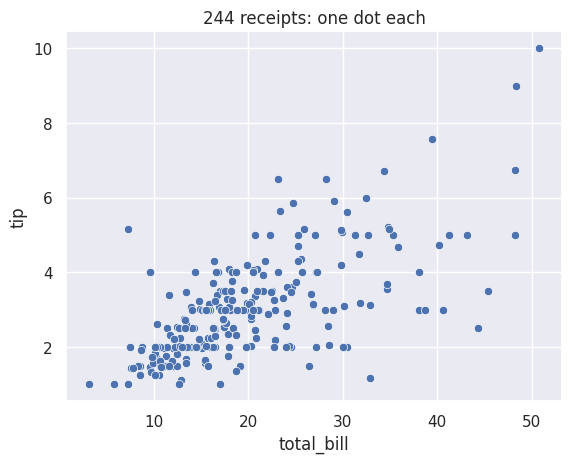

In [ ]:
sns.scatterplot(data=tips,
                x="total_bill",   # numeric → horizontal position
                y="tip")          # numeric → vertical position
plt.title("244 receipts: one dot each")
plt.show()

The cloud rises to the right — bigger bills do bring bigger tips.

**Now the magic word: `hue`.** One extra word adds a *third* column, by color:

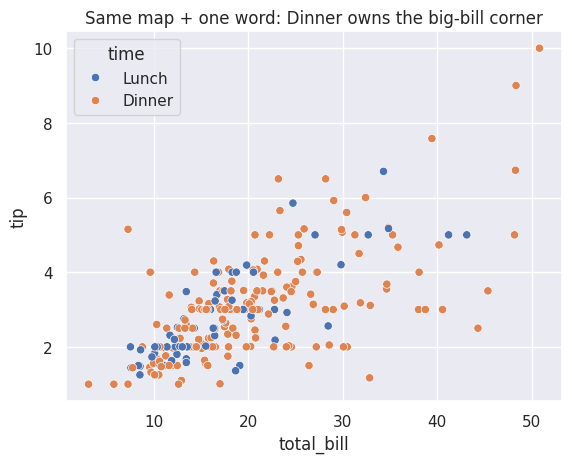

In [ ]:
sns.scatterplot(data=tips, x="total_bill", y="tip",
                hue="time")       # color the dots by Lunch / Dinner
plt.title("Same map + one word: Dinner owns the big-bill corner")
plt.show()

**Two bar plots that look alike and answer different questions.**
This is the classic beginner trap, so read slowly:

- `countplot` → **how many** receipts per day? (it just counts rows)
- `barplot` → what is the **average** tip per day? (it computes a mean per group)

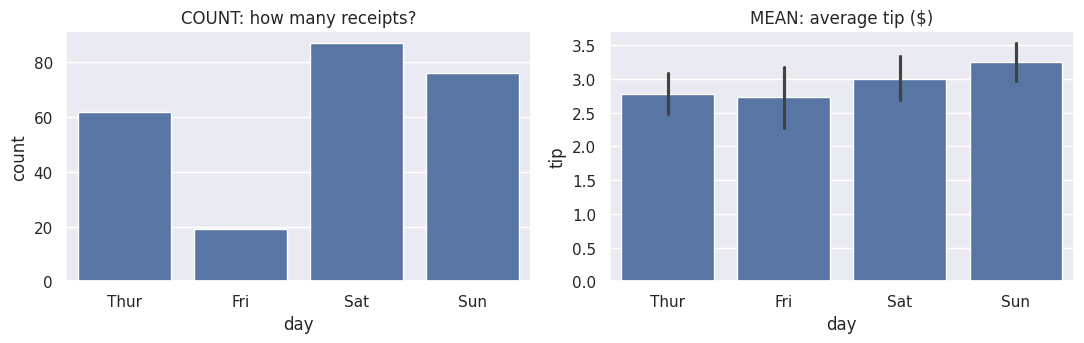

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

sns.countplot(data=tips, x="day", ax=axes[0])        # bar height = number of rows
axes[0].set_title("COUNT: how many receipts?")

sns.barplot(data=tips, x="day", y="tip", ax=axes[1]) # bar height = MEAN of tip
axes[1].set_title("MEAN: average tip ($)")

plt.tight_layout()
plt.show()

**How to read these charts — the two winners are different!**

| question | winner | the numbers |
|---|---|---|
| busiest day? (count) | **Saturday** | Thur 62 · Fri 19 · Sat **87** · Sun 76 |
| most generous day? (mean) | **Sunday** | \$2.77 · \$2.73 · \$2.99 · **\$3.26** |

The thin black line on each `barplot` bar is a **confidence interval** —
"the true average plausibly lives in this range". Friday's is the widest
because its mean rests on just **19 receipts**. Small groups = shaky averages.

> **Pitfall:** with thousands of dots a scatter becomes a smudge —
> add transparency: `sns.scatterplot(..., alpha=0.5)`.

---
## 7 · Correlation — one number for "moves together"

The scatter *showed* bills and tips rising together. **Correlation** (written
$r$) compresses that into one number between $-1$ and $+1$:

$$ r = \frac{\sum d^x_i \, d^y_i}{\sqrt{\sum (d^x_i)^2} \; \sqrt{\sum (d^y_i)^2}} $$

where $d^x_i = x_i - \bar{x}$ is just "how far above/below average". Same side
of average in both columns → positive products → positive $r$.

| $r$ | meaning |
|---|---|
| $+1$ | perfect sync (dancers in step) |
| $0$ | strangers |
| $-1$ | perfect mirror (one rises when the other falls) |

**By hand first** — five points, every step shown, then pandas checks us:

In [ ]:
x = pd.Series([1, 2, 3, 4, 5])
y = pd.Series([2, 4, 5, 4, 5])

dx = x - x.mean()                    # deviations from average: [-2,-1,0,1,2]
dy = y - y.mean()                    # deviations from average: [-2,0,1,0,1]
r_by_hand = (dx * dy).sum() / np.sqrt((dx**2).sum() * (dy**2).sum())

print(f"products sum = {(dx*dy ).sum()}   (4+0+0+0+2 = 6)")
print(f"r by hand    = 6/√(10×6) = {r_by_hand:.3f}")
print(f"pandas says  = {x.corr(y):.3f}   ← same answer, one method call")

products sum = 6.0   (4+0+0+0+2 = 6)
r by hand    = 6/√(10×6) = 0.775
pandas says  = 0.775   ← same answer, one method call


In [ ]:
# On the real receipts:
print("bill ↔ tip   r =", round(tips["total_bill"].corr(tips["tip"]), 3))

# And a hidden surprise — tip PERCENTAGE vs bill size:
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100   # new derived column
print("bill ↔ tip%  r =", round(tips["total_bill"].corr(tips["tip_pct"]), 3))

# Positive 0.676: bigger bills → bigger tips (in dollars).
# Negative -0.338: bigger bills → SMALLER tip percentage.
# Small tables are the generous ones — one line of code found that.

bill ↔ tip   r = 0.676
bill ↔ tip%  r = -0.339


> **Two famous pitfalls.**
> **1. Correlation ≠ causation.** Ice-cream sales correlate with sunburns —
> summer causes both; neither causes the other.
> **2. $r$ only sees straight lines.** Run the cell below: a *perfect* pattern,
> yet $r \approx 0$. Always plot the pair before trusting its $r$.

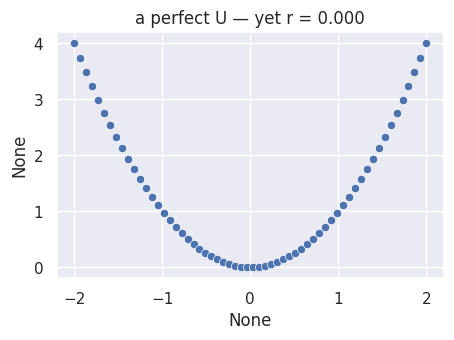

In [ ]:
u = pd.Series(np.linspace(-2, 2, 60))    # 60 evenly spaced x-values
v = u**2                                  # a PERFECT pattern: y = x²

fig, ax = plt.subplots(figsize=(5, 3.2))
sns.scatterplot(x=u, y=v, ax=ax)          # draw the U shape
ax.set_title(f"a perfect U — yet r = {u.corr(v):.3f}")
plt.show()
# r ≈ 0 because the left half cancels the right half. r is blind to curves.

---
## 8 · Heatmaps for correlation — the whole dataset in one glance

One $r$ per pair is fine for 2 columns. Four numeric columns = 6 pairs;
twenty columns = 190 pairs. Nobody reads 190 numbers — everyone reads a
**colored grid**. Like a weather map: numbers become temperature.

**Step 1 — build the matrix** (a table of $r$ for every pair):

In [ ]:
corr = tips[["total_bill", "tip", "size", "tip_pct"]].corr()
corr.round(2)

# Notice two things that are true of EVERY correlation matrix:
#  • the diagonal is all 1.00 (each column matches itself perfectly)
#  • it is symmetric (bill↔tip = tip↔bill) — the top triangle mirrors the bottom

,total_bill,tip,size,tip_pct
total_bill,1.00,0.68,0.60,-0.34
tip,0.68,1.00,0.49,0.34
size,0.60,0.49,1.00,-0.14
tip_pct,-0.34,0.34,-0.14,1.00


**Step 2 — paint it.** Each argument below earns its place; read the comments:

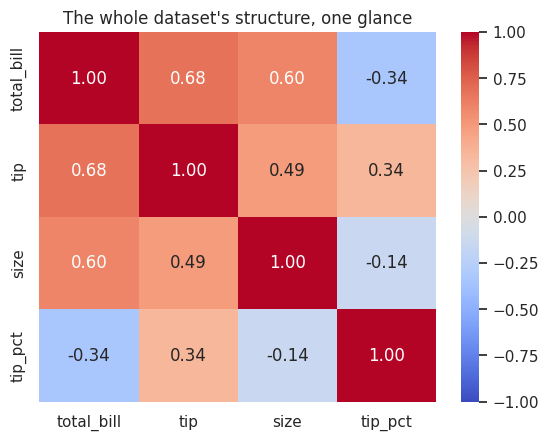

In [ ]:
sns.heatmap(corr,
            annot=True,        # write the number inside each cell
            fmt=".2f",         # …rounded to 2 decimals
            cmap="coolwarm",   # blue = negative, red = positive
            vmin=-1, vmax=1)   # pin the color scale to the FULL r range
plt.title("The whole dataset's structure, one glance")
plt.show()

**How to read this heatmap (worked reading, one cell):**
row `total_bill`, column `tip_pct` → $r = -0.34$, painted blue.
As bills get bigger, the tip *percentage* drops: a \$10 table tipping \$2
gives 20%; a \$50 table tipping \$5 gives 10%. One glance, one insight
the owner can act on.

**Three cheap pitfalls to avoid:**
1. **Unpinned colors** — without `vmin=-1, vmax=1`, weak correlations still
   scream in full red. Pin the scale on every correlation heatmap.
2. **Non-numeric columns** — `.corr()` needs numbers. Select them first:
   `tips.select_dtypes("number").corr()`.
3. **The heatmap inherits $r$'s blindness** — an $r \approx 0$ cell can hide
   a perfect curve. The heatmap says *where to look*; the scatter says *what is there*.

**Bonus (the pro look):** mask the repeated upper triangle —

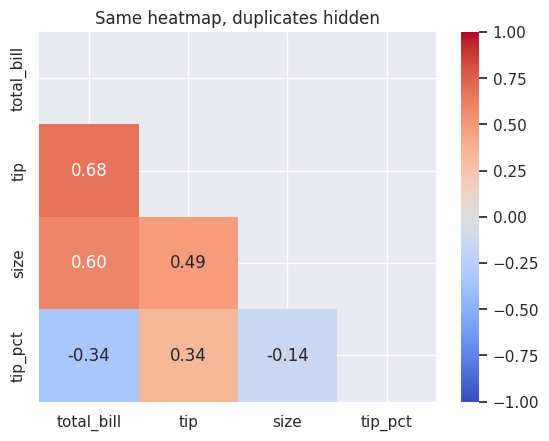

In [ ]:
masamask = np.triu(np.ones_like(corr, dtype=bool))   # True above the diagonal

sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1,
            mask=masamask)         # hide the mirrored half — less ink, same info
plt.title("Same heatmap, duplicates hidden")
plt.show()

---
## 9 · Matplotlib vs Seaborn — same chart, two ways

One task: **"average tip per day, as a bar chart."** We write it twice and
count the work. Same job, same data, same output — the fairest comparison.

**Round 1 — raw Matplotlib.** *You* do the statistics:

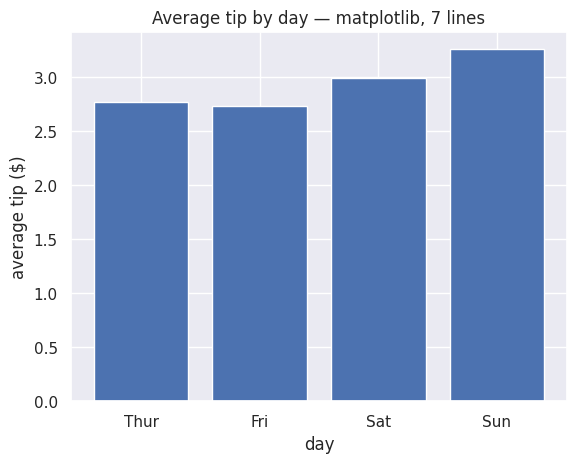

In [ ]:
avg = tips.groupby("day", observed=True)["tip"].mean()   # 1. compute means YOURSELF
order = ["Thur", "Fri", "Sat", "Sun"]
avg = avg.reindex(order)                    # 2. fix the weekday order yourself
plt.bar(order, avg.values)                  # 3. draw the bars
plt.xlabel("day")                           # 4. label x yourself…
plt.ylabel("average tip ($)")               # 5. …and y
plt.title("Average tip by day — matplotlib, 7 lines")   # 6. title
plt.show()                                  # 7. render

**Round 2 — Seaborn.** The statistics live *inside* the plot call:

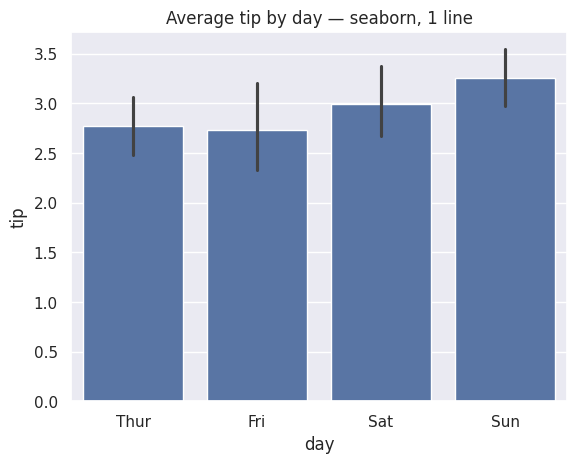

In [ ]:
sns.barplot(data=tips, x="day", y="tip")    # grouping, means, CIs, labels: DONE
plt.title("Average tip by day — seaborn, 1 line")
plt.show()

**The honest scorecard:**

| task | Matplotlib | Seaborn |
|---|---|---|
| statistical plots (box, violin, KDE, heatmap) | build by hand | **one line** |
| works directly with DataFrames | partly | **natively** |
| good-looking defaults | plain | **themed** |
| pixel-level control of anything | **total** | via matplotlib |
| unusual custom charts, animations | **yes** | not its job |

**The pro secret — it is not a fight.** Every seaborn plot *returns a
matplotlib object*. So the real workflow is: **Seaborn draws, Matplotlib polishes.**

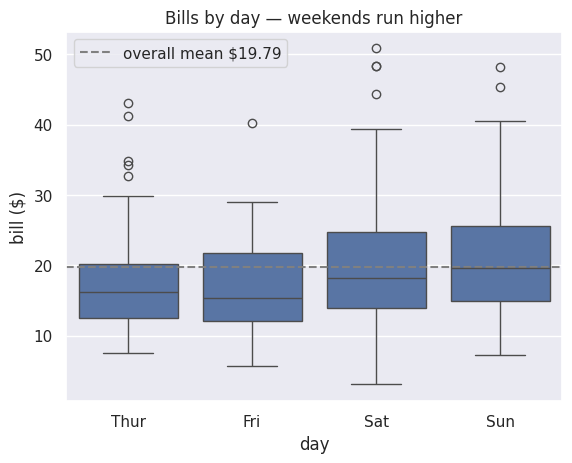

In [ ]:
ax = sns.boxplot(data=tips, x="day", y="total_bill")   # seaborn draws… and RETURNS the Axes

ax.set_title("Bills by day — weekends run higher")     # matplotlib polishes the SAME canvas
ax.set_ylabel("bill ($)")
ax.axhline(tips["total_bill"].mean(),                  # dashed line at the overall mean…
           ls="--", color="gray", label="overall mean $19.79")
ax.legend()                                            # show the label we just attached
plt.show()

# One matplotlib line (axhline) turned a chart into an argument:
# every day's box is now instantly readable as above/below average.


---
## 10 · Which plot when — the one-question method

Name your question, and the plot picks itself:

| your question | plot | one-liner |
|---|---|---|
| shape of one number? | histogram / KDE | `sns.histplot(data=t, x="total_bill", kde=True)` |
| compare groups on one number? | box / violin | `sns.boxplot(data=t, x="day", y="tip")` |
| two numbers together? | scatter | `sns.scatterplot(data=t, x="total_bill", y="tip")` |
| how many per category? | count | `sns.countplot(data=t, x="day")` |
| group averages? | bar | `sns.barplot(data=t, x="day", y="tip")` |
| every pair at once? | heatmap | `sns.heatmap(t.corr(numeric_only=True))` |

---
## ✍️ Practice — your turn (5–10 minutes)

Answer each with **one plot**. Solutions are at the bottom — try first!

1. What is the shape of the **tip** column? Is it right-skewed like the bills?
2. Do **smokers** and **non-smokers** differ in total_bill? (compare two groups)
3. Does **party size** relate to the tip? (two numbers… but size has few values —
   try both a scatter and a boxplot and decide which reads better)
4. Which **time** (Lunch/Dinner) brings more receipts? And which brings the
   higher *average* tip? (two different plots!)

In [ ]:
# Q1 — your code here:


In [ ]:
# Q2 — your code here:


In [ ]:
# Q3 — your code here:


In [ ]:
# Q4 — your code here:


---
### Solutions (no peeking until you tried)

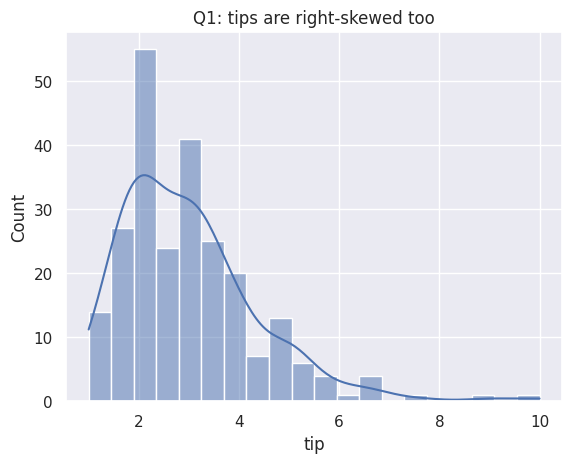

In [ ]:
# Q1 — tip shape: histogram + KDE. Yes: right-skewed, tail out to $10.
sns.histplot(data=tips, x="tip", bins=20, kde=True)
plt.title("Q1: tips are right-skewed too")
plt.show()

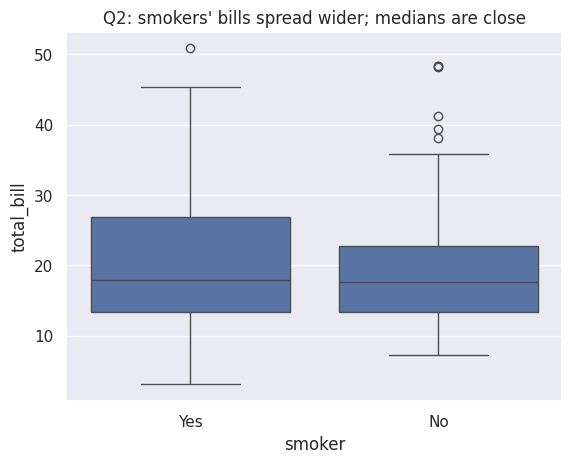

In [ ]:
# Q2 — two groups, one number → boxplot (category on x, number on y)
sns.boxplot(data=tips, x="smoker", y="total_bill")
plt.title("Q2: smokers' bills spread wider; medians are close")
plt.show()

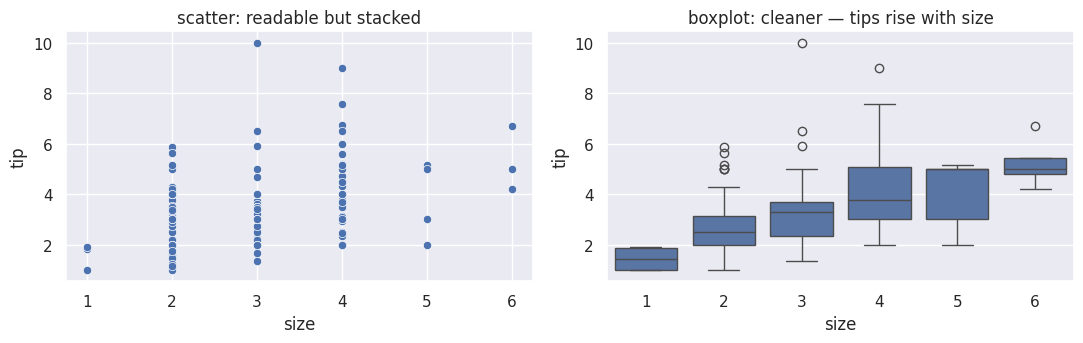

In [ ]:
# Q3 — size has only 6 distinct values → a boxplot per size reads better
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sns.scatterplot(data=tips, x="size", y="tip", ax=axes[0])   # dots stack into columns
axes[0].set_title("scatter: readable but stacked")
sns.boxplot(data=tips, x="size", y="tip", ax=axes[1])       # one box per party size
axes[1].set_title("boxplot: cleaner — tips rise with size")
plt.tight_layout()
plt.show()

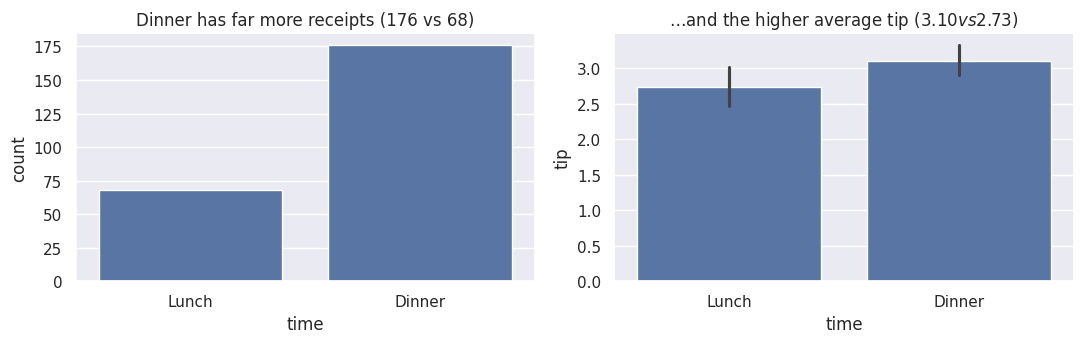

In [ ]:
# Q4 — COUNT vs MEAN: two different questions, two different plots
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sns.countplot(data=tips, x="time", ax=axes[0])              # how many receipts
axes[0].set_title("Dinner has far more receipts (176 vs 68)")
sns.barplot(data=tips, x="time", y="tip", ax=axes[1])       # average tip
axes[1].set_title("…and the higher average tip ($3.10 vs $2.73)")
plt.tight_layout()
plt.show()

---
## 11 · Bonus — interactive plots with Plotly

Everything so far produced a **static picture**: perfect for reports and slides.
One more library, **Plotly**, draws charts you can **touch** — hover for details,
zoom into a corner, pan around, click legend entries to hide a group.

Same idea as seaborn (`plotly.express` even uses the same words: `x`, `y`, `color`),
and Colab has it pre-installed. Watch the receipts introduce themselves:

In [ ]:
import plotly.express as px   # plotly express: one-line INTERACTIVE charts

fig = px.scatter(tips,                       # same table as all session
                 x="total_bill", y="tip",    # same axes as our seaborn scatter
                 color="time",               # same job as hue — Lunch vs Dinner
                 hover_data=["day", "size", "smoker"],  # what the tooltip reveals
                 title="Hover any dot — every receipt introduces itself")
fig.show()   # try it: hover, drag a box to zoom, double-click to reset

In [ ]:
# The histogram, upgraded: hover any bar for its exact range and count,
# and get a box plot thrown in on top (marginal="box") — two plots in one.
fig = px.histogram(tips,
                   x="total_bill",
                   nbins=20,                 # same 20 bins as before
                   marginal="box",           # add a box plot strip above
                   title="Bills: histogram + box, now zoomable")
fig.show()

In [ ]:
# Even the correlation heatmap can be interactive — hover a cell to read it.
fig = px.imshow(corr.round(2),               # the same 4×4 matrix from section 8
                text_auto=True,              # like annot=True
                color_continuous_scale="RdBu_r",  # like cmap="coolwarm"
                zmin=-1, zmax=1,             # like vmin/vmax — pin the scale
                title="Same heatmap — hover, zoom, inspect")
fig.show()

**So which library, when?** The full picture you now own:

| library | best at | output |
|---|---|---|
| **Matplotlib** | pixel-level control, custom figures | static |
| **Seaborn** | statistical plots in one line | static |
| **Plotly** | exploring data, dashboards, demos | **interactive** |

For EDA and reports, seaborn + matplotlib remain your daily drivers.
Reach for Plotly when someone will *explore* the chart rather than *read* it.
In Module 4 you will go further down this road — interactive dashboards
with Tableau / Power BI build on exactly this idea.

---
## Key takeaways — the whole session in five lines

1. **Plots exist because summaries lie** (Anscombe's quartet).
2. **One grammar rules Seaborn:** `sns.plotname(data=df, x=…, y=…, hue=…)`.
3. **Statistical plots answer question shapes:** histogram → shape,
   box/violin → compare groups, scatter → two numbers, count vs bar → count vs mean.
4. **Correlation** puts a number on "moves together" ($-1$ to $+1$, straight
   lines only!) and the **heatmap** shows every pair at once —
   `annot=True, cmap="coolwarm", vmin=-1, vmax=1`.
5. **Matplotlib vs Seaborn is a stack, not a fight:** seaborn draws (1 line),
   matplotlib polishes (`ax.set_title`, `ax.axhline`, `plt.savefig`).

**Next session → Module 3: SQL.** Today you explored 244 rows in memory.
Real companies keep 244 *million* rows in databases — SQL is how you ask them
questions, and every chart you drew today will sit at the end of a SQL query.

*See you there.*